In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

In [ ]:
qSales = pd.read_csv('qSales_2024.csv')
display(qSales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,102450,2022-12-31,2022,3,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2022Q4,2022Q3,5280.78,A
273,102450,2023-03-31,2022,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q1,2022Q4,2226.88,A
274,102450,2023-06-30,2023,1,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q2,2023Q1,3190.81,A
275,102450,2023-09-30,2023,2,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q3,2023Q2,2140.04,A


In [ ]:
target_sales = qSales.loc[qSales['tic'] == 'TGT']
target_sales['datadate'] = pd.to_datetime(target_sales['datadate'])
display(target_sales)

/tmp/ipykernel_1737/1101881082.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['datadate'] = pd.to_datetime(target_sales['datadate'])


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A


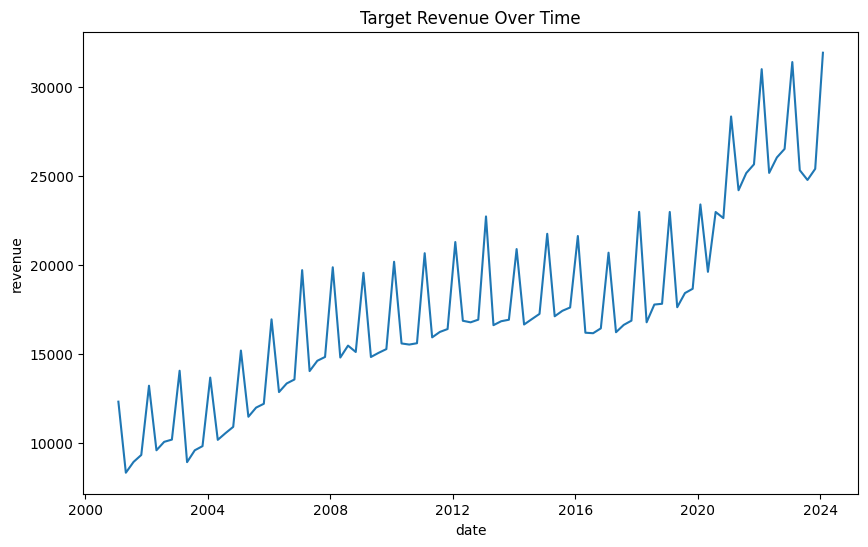

In [ ]:
# Visualize the data to identify underlying patterns

plt.figure(figsize=(10, 6))
plt.title('Target Revenue Over Time')
plt.xlabel('date')
plt.ylabel('revenue')
plt.plot(target_sales['datadate'], target_sales['saleq'])


In [ ]:
# create a new column called time, independent variable

target_sales['time'] = range(1, len(target_sales) + 1)
display(target_sales)

/tmp/ipykernel_1737/220950177.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['time'] = range(1, len(target_sales) + 1)


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92


In [ ]:
target_sales['christmas_DV'] = np.where(target_sales['fqtr']==4,1,0)
target_sales['christmas_DV_interaction'] = target_sales['time'] * target_sales['christmas_DV']

target_sales['backtoschool_DV'] = np.where(target_sales['fqtr']==3, 1, 0)
target_sales['backtoschool_DV_interaction'] = target_sales['time'] * target_sales['backtoschool_DV']

display(target_sales)

/tmp/ipykernel_1737/2917395713.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['christmas_DV'] = np.where(target_sales['fqtr']==4,1,0)
/tmp/ipykernel_1737/2917395713.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['christmas_DV_interaction'] = target_sales['time'] * target_sales['christmas_DV']
/tmp/ipykernel_1737/2917395713.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inste

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,datafqtr,saleq,costat,time,christmas_DV,christmas_DV_interaction,backtoschool_DV,backtoschool_DV_interaction,covid_DV,covid_DV_interaction
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,...,2000Q4,12324.00,A,1,1,1,0,0,0,0
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,...,2001Q1,8334.00,A,2,0,0,0,0,0,0
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,...,2001Q2,8941.00,A,3,0,0,0,0,0,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,...,2001Q3,9331.00,A,4,0,0,1,4,0,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,...,2001Q4,13220.00,A,5,1,5,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,...,2022Q4,31395.00,A,89,1,89,0,0,1,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,...,2023Q1,25322.00,A,90,0,0,0,0,1,90
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,...,2023Q2,24773.00,A,91,0,0,0,0,1,91
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,...,2023Q3,25398.00,A,92,0,0,1,92,1,92


In [ ]:
# split the data into training and testing

dt4training = target_sales[:int(0.75* len(target_sales))]
dt4testing = target_sales[int(0.75 * len(target_sales)):]

display(dt4testing)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,datafqtr,saleq,costat,time,christmas_DV,christmas_DV_interaction,backtoschool_DV,backtoschool_DV_interaction,covid_DV,covid_DV_interaction
161,3813,2018-04-30,2018,1,1,INDL,C,D,STD,TGT,...,2018Q1,16781.00,A,70,0,0,0,0,0,0
162,3813,2018-07-31,2018,2,1,INDL,C,D,STD,TGT,...,2018Q2,17777.00,A,71,0,0,0,0,0,0
163,3813,2018-10-31,2018,3,1,INDL,C,D,STD,TGT,...,2018Q3,17821.00,A,72,0,0,1,72,0,0
164,3813,2019-01-31,2018,4,1,INDL,C,D,STD,TGT,...,2018Q4,22977.00,A,73,1,73,0,0,0,0
165,3813,2019-04-30,2019,1,1,INDL,C,D,STD,TGT,...,2019Q1,17627.00,A,74,0,0,0,0,0,0
166,3813,2019-07-31,2019,2,1,INDL,C,D,STD,TGT,...,2019Q2,18422.00,A,75,0,0,0,0,0,0
167,3813,2019-10-31,2019,3,1,INDL,C,D,STD,TGT,...,2019Q3,18664.00,A,76,0,0,1,76,0,0
168,3813,2020-01-31,2019,4,1,INDL,C,D,STD,TGT,...,2019Q4,23399.00,A,77,1,77,0,0,0,0
169,3813,2020-04-30,2020,1,1,INDL,C,D,STD,TGT,...,2020Q1,19615.00,A,78,0,0,0,0,1,78
170,3813,2020-07-31,2020,2,1,INDL,C,D,STD,TGT,...,2020Q2,22975.00,A,79,0,0,0,0,1,79


In [ ]:
# TRAINING

x = dt4training.loc[:,['time','christmas_DV','christmas_DV_interaction','backtoschool_DV','backtoschool_DV_interaction']]
x = sm.add_constant(x)
y = dt4training.loc[:,'saleq']

model_dummy = sm.OLS(y,x).fit()
model_dummy.params

,0
const,9372.70
time,136.25
christmas_DV,4104.75
christmas_DV_interaction,14.17
backtoschool_DV,312.38
backtoschool_DV_interaction,-4.46


In [ ]:
# TESTING

x_test = dt4testing.loc[:,['time','christmas_DV','christmas_DV_interaction','backtoschool_DV','backtoschool_DV_interaction']]
x_test = sm.add_constant(x_test)

In [ ]:
# MAPE SCORE

model_assessment = dt4testing.copy()
model_assessment['model_predicted_rev'] = model_dummy.predict(x_test)

model_assessment['model_APE'] = abs(
    (
    model_assessment['saleq'] - model_assessment['model_predicted_rev']
    ) / model_assessment['saleq']
    )

display(model_assessment)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,costat,time,christmas_DV,christmas_DV_interaction,backtoschool_DV,backtoschool_DV_interaction,covid_DV,covid_DV_interaction,model_predicted_rev,model_APE
161,3813,2018-04-30,2018,1,1,INDL,C,D,STD,TGT,...,A,70,0,0,0,0,0,0,18910.26,0.13
162,3813,2018-07-31,2018,2,1,INDL,C,D,STD,TGT,...,A,71,0,0,0,0,0,0,19046.51,0.07
163,3813,2018-10-31,2018,3,1,INDL,C,D,STD,TGT,...,A,72,0,0,1,72,0,0,19174.21,0.08
164,3813,2019-01-31,2018,4,1,INDL,C,D,STD,TGT,...,A,73,1,73,0,0,0,0,24458.49,0.06
165,3813,2019-04-30,2019,1,1,INDL,C,D,STD,TGT,...,A,74,0,0,0,0,0,0,19455.26,0.10
166,3813,2019-07-31,2019,2,1,INDL,C,D,STD,TGT,...,A,75,0,0,0,0,0,0,19591.51,0.06
167,3813,2019-10-31,2019,3,1,INDL,C,D,STD,TGT,...,A,76,0,0,1,76,0,0,19701.39,0.06
168,3813,2020-01-31,2019,4,1,INDL,C,D,STD,TGT,...,A,77,1,77,0,0,0,0,25060.19,0.07
169,3813,2020-04-30,2020,1,1,INDL,C,D,STD,TGT,...,A,78,0,0,0,0,1,78,20000.26,0.02
170,3813,2020-07-31,2020,2,1,INDL,C,D,STD,TGT,...,A,79,0,0,0,0,1,79,20136.51,0.12


In [ ]:
print(model_assessment['model_APE'].mean() * 100,'%')

12.020196145122915 %


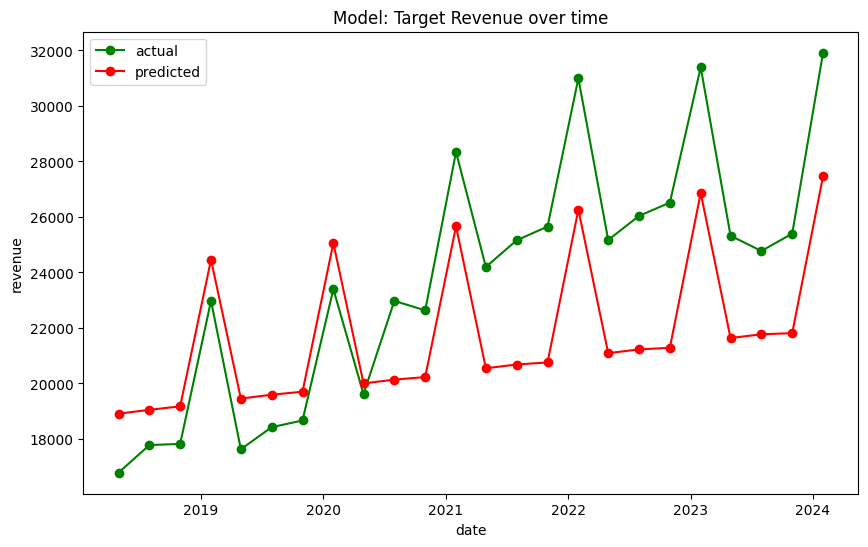

In [ ]:
# create Model visualization to show actual vs predicted

plt.figure(figsize =(10,6))
plt.title('Model: Target Revenue over time')
plt.ylabel('revenue')
plt.xlabel('date')

plt.plot(model_assessment['datadate'], model_assessment['saleq'], marker='o', color = 'green', label = 'actual')
plt.plot(model_assessment['datadate'], model_assessment['model_predicted_rev'], marker='o',color='red', label = 'predicted')
plt.legend()

# Brief Memo to Chapman Wealth Management

Re: Target Quarterly Revenue Regression Analysis

The regression model analyzes Target's quarterly revenue to predict revenue (saleq) using a time independent variable and two dummy variables: christmas_DV (Q4) and backtoschool_DV (Q3).

The christmas_DV captures the increase in revenue during Target's Q4, which corresponds to the holiday shopping season with increased consumer spending on gifts and decorations. The backtoschool_DV captures Q3, when demand typically rises because of purchases related to the start of the school year, including school supplies and new clothes.

The model has a MAPE score of about 12%, indicating that it predicts quarterly revenue with good accuracy. The visualization chart also shows that predicted results follow a similar pattern as the actual results for the testing data from Target's 2018Q1- 2023Q4.

This suggests that Target has stable long-term revenue growth and predictable seasonal demand, making its revenue performance relatively reliable for forecasting and decided what to invest more resources in